### Imports and Configurations

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# --- Import from your new libraries ---
from src.data_loader import *
from src.ism_utils import *

# --- Config ---
CHROM_ID = "HPRT1R"
FA_PATH = Path("Data/genome/HPRT1R.fa")

# Genomic ISM maps paths
ISM_GENOMIC_FWD = "ISM/Maps/HPRT1R/genomic_model_chr_HPRT1R_fwd.dat"
ISM_GENOMIC_REV = "ISM/Maps/HPRT1R/genomic_model_chr_HPRT1R_rev.dat"

# Random ISM maps paths
ISM_RANDOM_FWD  = "ISM/Maps/HPRT1R/HPRT1R_model_chr_HPRT1R_fwd.dat"
ISM_RANDOM_REV  = "ISM/Maps/HPRT1R/HPRT1R_model_chr_HPRT1R_rev.dat"

# Model paths
GENOMIC_MODEL = "Distillation/genomic/student_genomic_distilled.h5"
RANDOM_MODEL = "Distillation/HPRT1R/student_HPRT1R_distilled.h5"
PARAMS_JSON = "Models/shorkie/params.json"

# Normalized coverage data paths
NPZ_COV_FWD = "Data/normalized_expression/HPRT1R_fwd_norm.npz"
NPZ_COV_REV = "Data/normalized_expression/HPRT1R_rev_norm.npz"

# Motif database path
MEME_DB_PATH     =  "Data/motifs/SwissRegulon.meme"       #"Data/motifs/YeTFaSCo.meme"

# Analysis Parameters
WINDOW_SIZE = 150

# P-val threshold for motif scanning
threshold = 0.001

# Normalization mean and std for inverse-transform of predictions
mu_r, sigma_r = 4.5184 ,1.7808
mu_g, sigma_g = 1.7390, 1.8168


OUT_DIR = Path("ISM/Notebook_output/HPRT1R/disagreement_windows_with_profiles")
OUT_DIR.mkdir(parents=True, exist_ok=True)



2026-01-15 17:39:22.065841: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 17:39:22.106191: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-15 17:39:22.106219: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-15 17:39:22.107279: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-15 17:39:22.114065: I tensorflow/core/platform/cpu_feature_guar

### Load data

In [2]:
# 1. Load Sequence
full_seq = fetch_chr_seq(FA_PATH, CHROM_ID)
L = len(full_seq)
fwd_seq = full_seq
rev_seq = str(Seq(fwd_seq).reverse_complement())

print(f"Loaded sequence length: {L}")

# 2. Load ISM Scores (Memmap)
# FWD ISM scores
ism_gen_fwd = np.array(np.memmap(ISM_GENOMIC_FWD, dtype="float32", mode="r", shape=(len(full_seq), 4)))
ism_rand_fwd = np.array(np.memmap(ISM_RANDOM_FWD, dtype="float32", mode="r", shape=(len(full_seq), 4)))

# REV ISM scores
ism_gen_rev = np.array(np.memmap(ISM_GENOMIC_REV, dtype="float32", mode="r", shape=(len(full_seq), 4)))
ism_rand_rev = np.array(np.memmap(ISM_RANDOM_REV, dtype="float32", mode="r", shape=(len(full_seq), 4)))

# 3. Compute nucleotide level contributions from ISM matrices
_, attr_gen_fwd = compute_attr_from_ism(ism_gen_fwd, fwd_seq)
_, attr_gen_rev = compute_attr_from_ism(ism_gen_rev, rev_seq)

_, attr_rand_fwd = compute_attr_from_ism(ism_rand_fwd, fwd_seq)
_, attr_rand_rev = compute_attr_from_ism(ism_rand_rev, rev_seq)

# One-hot encode fwd & rev sequence
onehot_fwd = one_hot(fwd_seq).astype(np.float32)
onehot_rev = one_hot(rev_seq).astype(np.float32)


Loaded sequence length: 113995


### Compute correlations

Compute window correlations

In [3]:

def windowed_corr(x, y, win=400, stride=200, method="pearson", min_valid=10):
    """
    Sliding-window correlation between x and y.
    method: "pearson" or "spearman"
    min_valid: minimum number of finite paired points required in a window
    Returns:
        starts : (n_windows,) window start indices
        corrs  : (n_windows,) correlation per window (NaN if not computable)
    """
    x = np.asarray(x)
    y = np.asarray(y)
    assert x.shape == y.shape

    L = len(x)
    starts = np.arange(0, L - win + 1, stride, dtype=int)
    corrs = np.full(len(starts), np.nan, dtype=float)

    for i, s in enumerate(starts):
        a = x[s:s+win]
        b = y[s:s+win]

        # keep only finite pairs
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() < min_valid:
            continue

        a = a[m]
        b = b[m]

        # constant windows (after filtering)
        if np.all(a == a[0]) or np.all(b == b[0]):
            continue

        if method == "pearson":
            corrs[i] = pearsonr(a, b)[0]
        elif method == "spearman":
            corrs[i] = spearmanr(a, b)[0]
        else:
            raise ValueError("method must be 'pearson' or 'spearman'")

    return starts, corrs

### Generate correlation statistics

In [4]:
## generate correlations for both fwd and rev strands
_ , corrs_fwd = windowed_corr(attr_gen_fwd, attr_rand_fwd, win=150, stride=75, method="pearson")
_ , corrs_rev = windowed_corr(attr_gen_rev, attr_rand_rev, win=150, stride=75, method="pearson")

corrs = np.concatenate([corrs_fwd, corrs_rev])

valid = corrs[np.isfinite(corrs)]
print("Number of windows:", len(corrs))
print("Valid correlations:", len(valid))
print("Median Pearson r:", np.median(valid))
print("Mean Pearson r:", np.mean(valid))

Number of windows: 3036
Valid correlations: 2680
Median Pearson r: 0.18513602995444356
Mean Pearson r: 0.16311770247819898


### Plot correlations histogrm

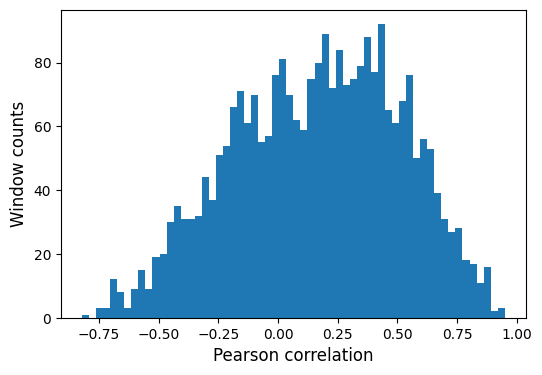

In [5]:
plt.figure(figsize=(6,4))
plt.hist(valid, bins=60)
plt.xlabel("Pearson correlation",size=12)
plt.ylabel("Window counts",size=12)
# plt.title("Windowed Spearman correlations")
# plt.axvline(np.median(valid), linestyle="--")
# plt.savefig("ISM/correlations_histogram", dpi=300)
plt.show()

### Handle Nan values

In [6]:
# Examine Nans in attribution maps
print("NaNs genomic fwd:", np.sum(np.isnan(attr_gen_fwd)))
print("NaNs genomic rev:", np.sum(np.isnan(attr_gen_rev)))
print("NaNs random fwd:", np.sum(np.isnan(attr_rand_fwd)))
print("NaNs random rev:", np.sum(np.isnan(attr_rand_rev)))

# Turn Nans to zeros
attr_gen_fwd = np.nan_to_num(attr_gen_fwd, nan=0.0, posinf=0.0, neginf=0.0)
attr_gen_rev = np.nan_to_num(attr_gen_rev, nan=0.0, posinf=0.0, neginf=0.0)

attr_rand_fwd = np.nan_to_num(attr_rand_fwd, nan=0.0, posinf=0.0, neginf=0.0)
attr_rand_rev = np.nan_to_num(attr_rand_rev, nan=0.0, posinf=0.0, neginf=0.0)

NaNs genomic fwd: 4
NaNs genomic rev: 0
NaNs random fwd: 0
NaNs random rev: 0


### Find & Annotate Seqlets

In [7]:
# attr_gen_fwd, attr_gen_rev are shape (L,)
attr_gen= np.stack([attr_gen_fwd, attr_gen_rev], axis=0)

# same for random
attr_rand = np.stack([attr_rand_fwd, attr_rand_rev], axis=0)

print("Shape of concatenated attributions: ", attr_gen.shape)

onehot = np.stack([onehot_fwd, onehot_rev], axis=0)

# 1. Find Seqlets (Regions of high importance)

s_gen = find_seqlets(attr_gen, threshold=threshold)
s_rand = find_seqlets(attr_rand, threshold=threshold)

print(f"Found {len(s_gen)} genomic seqlets and {len(s_rand)} random/Mpneumo seqlets.")

# 2. Annotate with Motifs
print(f"Annotating with {MEME_DB_PATH}...")
s_gen = annotate_seqlets_with_motifs(s_gen, onehot, MEME_DB_PATH)
s_rand = annotate_seqlets_with_motifs(s_rand, onehot, MEME_DB_PATH)

# Optional: Peek at the top motifs found
print("\nTop Motifs found in Random Model:")
print(s_rand[s_rand.motif_name != "NA"].motif_name.value_counts())

Shape of concatenated attributions:  (2, 113995)
Found 343 genomic seqlets and 792 random/Mpneumo seqlets.
Annotating with Data/motifs/SwissRegulon.meme...
X_seq shape:  torch.Size([2, 4, 113995])
Significant motif hits kept: 89
Unique seqlets annotated: NA
X_seq shape:  torch.Size([2, 4, 113995])
Significant motif hits kept: 181
Unique seqlets annotated: NA

Top Motifs found in Random Model:
SIG1          38
ORC1          25
MATALPHA2      8
SPT15          8
REB1           8
SFP1           5
CST6           5
YAP3           5
STB3           4
AZF1           4
PDR8           4
SKO1           4
RGM1           4
PBF1           3
YPR022C        3
CBF1           3
CIN5           3
HMRA2          2
YDR520C        2
AFT2           2
MAC1           2
RPH1           2
SIP4           2
RTG3           2
TYE7           2
YER130C        2
SUT2           2
PBF2           2
YNR063W        1
STE12          1
INO4           1
INO2           1
RAP1           1
FKH1           1
FKH2           1
FZF1     

In [8]:
print(s_rand[s_rand.motif_name != "NA"].motif_name.unique().tolist())

['ORC1 ', 'MAC1 ', 'SIG1 ', 'STB4 ', 'REB1 ', 'GCN4 ', 'YAP3 ', 'YER130C ', 'SIP4 ', 'YPR022C ', 'PBF1 ', 'PBF2 ', 'MATALPHA2 ', 'SNT2 ', 'ABF2 ', 'SKO1 ', 'RGM1 ', 'SFP1 ', 'CAD1 ', 'SPT15 ', 'NHP6A ', 'TOS8 ', 'AZF1 ', 'TBF1 ', 'CIN5 ', 'SUT2 ', 'CST6 ', 'CBF1 ', 'TYE7 ', 'RTG3 ', 'STB3 ', 'RPH1 ', 'PDR8 ', 'YDR520C ', 'LYS14 ', 'EDS1 ', 'SWI4 ', 'HMRA2 ', 'CUP9 ', 'YPR015C ', 'YNR063W ', 'HAP4 ', 'PDR3 ', 'PDR1 ', 'AFT2 ', 'FZF1 ', 'FKH2 ', 'FKH1 ', 'RAP1 ', 'INO2 ', 'INO4 ', 'STE12 ', 'GAT1 ']


### Load models for prediction

In [9]:

from baskerville.seqnn import SeqNN
import json

def load_model(model_path):

    with open(PARAMS_JSON) as f:
        params = json.load(f)

    params["model"]["num_features"] = 170
    m = SeqNN(params["model"])
    trunk_out = m.model_trunk.output
    
    # Distillation Head
    y = tf.keras.layers.Dense(1, name="distill_head")(trunk_out)
    y = tf.keras.layers.Lambda(lambda t: tf.squeeze(t, -1))(y)
    student = tf.keras.Model(inputs=m.model.input, outputs=y)

    # --- Weight Check ---
    head_layer = student.get_layer("distill_head")
    head_before = [w.numpy() for w in head_layer.weights]
    trunk_before = [w.numpy().copy() for w in m.model_trunk.weights]

    # load weights
    student.load_weights(model_path)

    # ensure weights changed
    head_after = [w.numpy() for w in head_layer.weights]
    trunk_after = [w.numpy() for w in m.model_trunk.weights]

    trunk_changed = any(np.any(b != a) for b, a in zip(trunk_before, trunk_after))
    head_changed  = any(np.any(b != a) for b, a in zip(head_before, head_after))

    print(f"    Trunk weights changed? {trunk_changed}")
    print(f"    Head weights changed?  {head_changed}")

    return student

genomic_model = load_model(GENOMIC_MODEL)
random_model  = load_model(RANDOM_MODEL)


2026-01-15 17:39:39.928546: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 76327 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:65:00.0, compute capability: 8.0
2026-01-15 17:39:39.930641: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 44469 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:ca:00.0, compute capability: 8.0


    Trunk weights changed? True
    Head weights changed?  True
    Trunk weights changed? True
    Head weights changed?  True


### Plot windows and predict

In [ ]:


print(f"Current number of significant random motifs {len(s_rand)}")

## choose windows based on correlation
selected_windows = choose_disagreement_windows(s_rand, attr_gen,attr_rand, window_size=WINDOW_SIZE)

print(f"Selected {len(selected_windows)} low-correlation windows")

for i, (s, ws, we, r) in enumerate(selected_windows):

    strand = 'fwd' if s==0 else 'rev'

    print(f"[{i+1}/{len(selected_windows)}] Window {ws}-{we} strand: {strand} correlation: {r:.4f}")

    seq = fwd_seq if s==0 else rev_seq

    coverage_npz = NPZ_COV_FWD if s==0 else NPZ_COV_REV

    plot_comparison_with_metrics(
        seq=seq,
        strand=strand,
        attr_gen=attr_gen,
        seqlets_gen=s_gen,
        attr_rand=attr_rand,
        seqlets_rand=s_rand,
        ws=ws,
        we=we,
        out_dir=OUT_DIR,

        # ---- models ----
        model_random = random_model,
        model_genomic =genomic_model,

        # ---- truth ----
        npz_truth_path=coverage_npz,
        chrom=CHROM_ID,

        # ---- normalization ----
        mu_g=mu_g,
        sigma_g=sigma_g,
        mu_r=mu_r,
        sigma_r=sigma_r,

        correlation =r
    )